In [737]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pipeline import dataset
import joblib
import optuna
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from utils import acc, precis, recall, f1

import warnings
warnings.filterwarnings('ignore')

In [738]:
DATASET_CONF = [
  {
    "name": "mojokerto", 
    "tif_path": "Data/mojokerto/feature11", 
    "label_path": "Data/mojokerto/label/label1.tif"
  },
  {
    "name": "samodra_A", 
    "tif_path": "Data/samodra/A", 
    "label_path": "Data/samodra/label/A/label.tif"
  },
  {
    "name": "samodra_B", 
    "tif_path": "Data/samodra/B", 
    "label_path": "Data/samodra/label/B/label.tif"
  }
]

In [739]:
df_list = []
for config in DATASET_CONF:
    train_df, val_df, _ = dataset.get_ML_data(config["tif_path"], config["label_path"])
    df = pd.concat([train_df, val_df], axis=0, ignore_index=True)
    df['lokasi'] = config["name"]
    df_list.append(df)

final_df = pd.concat(df_list, axis=0, ignore_index=True)

(420, 11) (180, 11) (420, 1) (180, 1)
(210, 11) (91, 11) (210, 1) (91, 1)
(356, 11) (353, 11) (356, 1) (353, 1)


In [740]:
final_df.to_csv("Data/combined_dataset.csv", index=False)

In [741]:
df_mjk = final_df[final_df['lokasi'] == 'mojokerto']
df_sam_A = final_df[final_df['lokasi'] == 'samodra_A']
df_sam_B = final_df[final_df['lokasi'] == 'samodra_B']

## EDA

In [742]:
print(final_df['lokasi'].value_counts())

lokasi
samodra_B    709
mojokerto    600
samodra_A    301
Name: count, dtype: int64


In [743]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   aspect   1610 non-null   float64
 1   elevasi  1610 non-null   float64
 2   geologi  1610 non-null   float64
 3   jalan    1610 non-null   float64
 4   landuse  1610 non-null   float64
 5   plan     1610 non-null   float64
 6   prof     1610 non-null   float64
 7   slope    1610 non-null   float64
 8   spi      1610 non-null   float64
 9   sungai   1610 non-null   float64
 10  twi      1610 non-null   float64
 11  label    1610 non-null   float64
 12  lokasi   1610 non-null   object 
dtypes: float64(12), object(1)
memory usage: 163.6+ KB


In [744]:
df_mjk.describe()

,aspect,elevasi,geologi,jalan,landuse,plan,prof,slope,spi,sungai,twi,label
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,0.491289,0.211154,0.519556,0.090227,0.190370,0.751346,0.405636,0.329745,0.013379,0.241834,0.240263,0.500000
std,0.286970,0.144512,0.224792,0.138770,0.248439,0.077187,0.078731,0.244734,0.082509,0.217234,0.170727,0.500417
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001487,-0.000010,0.000000,-0.022739,0.000000
25%,0.245817,0.113784,0.400000,0.016287,0.000000,0.718794,0.372366,0.099455,0.000510,0.065547,0.126039,0.000000
50%,0.490214,0.185420,0.466667,0.042287,0.000000,0.750851,0.406806,0.291510,0.001696,0.169003,0.204014,0.500000
75%,0.735990,0.284370,0.733333,0.094711,0.333333,0.786124,0.436717,0.516400,0.004479,0.380206,0.299071,1.000000
max,1.000000,1.022069,1.000000,1.032598,1.000000,1.118500,1.000000,1.000000,1.455557,1.000000,1.000000,1.000000


In [745]:
df_sam_A.describe()

,aspect,elevasi,geologi,jalan,landuse,plan,prof,slope,spi,sungai,twi,label
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,3.010000e+02,301.000000,301.000000
mean,0.466426,0.515968,0.633001,0.177558,0.545455,0.538814,0.398993,0.349994,0.648290,1.092193e-01,0.146746,0.637874
std,0.288417,0.257006,0.384173,0.180753,0.270292,0.080490,0.124379,0.219412,0.143375,1.619689e-01,0.141729,0.481415
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.032256,0.000000,-0.310330,-3.255015e-09,-0.001069,0.000000
25%,0.219564,0.309719,0.200000,0.051666,0.363636,0.515440,0.322581,0.167901,0.594833,2.316304e-02,0.065206,0.000000
50%,0.450096,0.570258,0.833333,0.113765,0.545455,0.539193,0.387097,0.333333,0.641793,4.635826e-02,0.101016,1.000000
75%,0.702277,0.732631,1.000000,0.224764,0.727273,0.570072,0.451614,0.520988,0.720669,1.196435e-01,0.172100,1.000000
max,1.002813,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.151519,1.000000e+00,1.000000,1.000000


In [746]:
df_sam_B.describe()

,aspect,elevasi,geologi,jalan,landuse,plan,prof,slope,spi,sungai,twi,label
count,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000
mean,0.486124,0.438213,0.574706,0.229656,0.503398,0.410034,0.546544,0.451818,0.639929,0.153834,0.143937,0.421721
std,0.298935,0.232162,0.388338,0.224082,0.371390,0.088122,0.129622,0.201618,0.113245,0.157326,0.112138,0.494183
min,0.000000,0.000000,0.000000,0.000000,0.000000,-0.139537,-0.218749,-0.006961,0.000000,0.000000,-0.009639,0.000000
25%,0.220028,0.248534,0.166667,0.059327,0.090909,0.378737,0.468750,0.310905,0.601380,0.044368,0.076506,0.000000
50%,0.465927,0.429590,0.800000,0.154916,0.545455,0.408637,0.562500,0.450116,0.647318,0.109418,0.114458,0.000000
75%,0.749656,0.616148,1.000000,0.337891,0.818182,0.438538,0.625000,0.596288,0.699480,0.211164,0.166868,1.000000
max,1.000560,1.021110,1.000000,1.162644,1.000000,1.000000,1.000000,1.039443,1.035868,1.000000,1.000000,1.000000


In [747]:
features = [col for col in df.columns if col not in ['label', 'lokasi']]
cat_cols = ['geologi', 'landuse']
num_cols = [col for col in features if col not in cat_cols]
locations = df['lokasi'].unique()

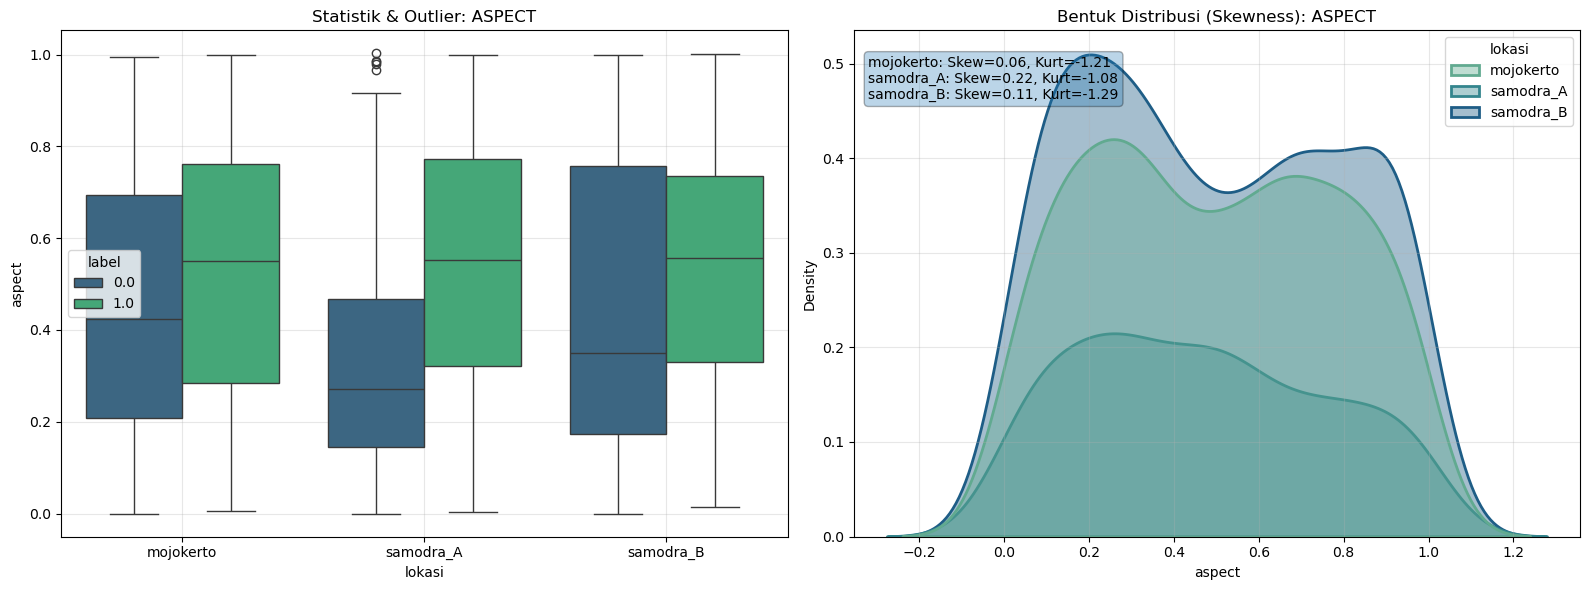

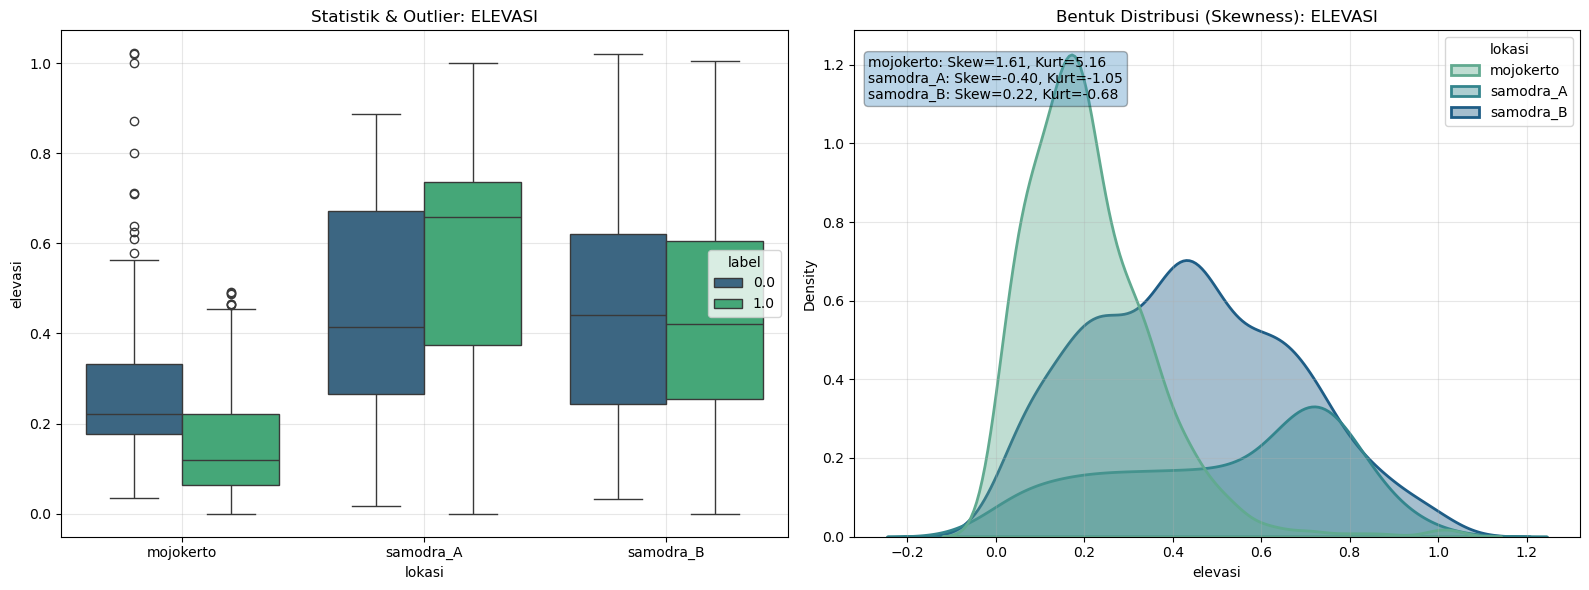

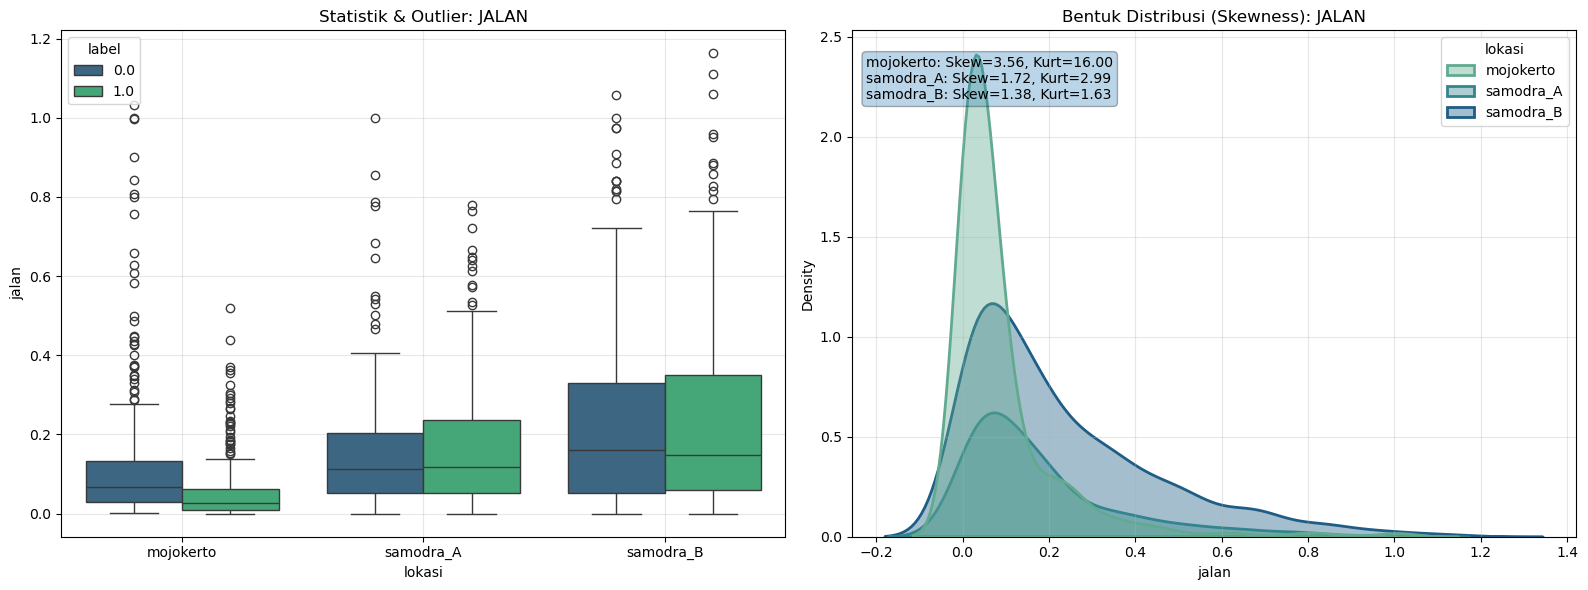

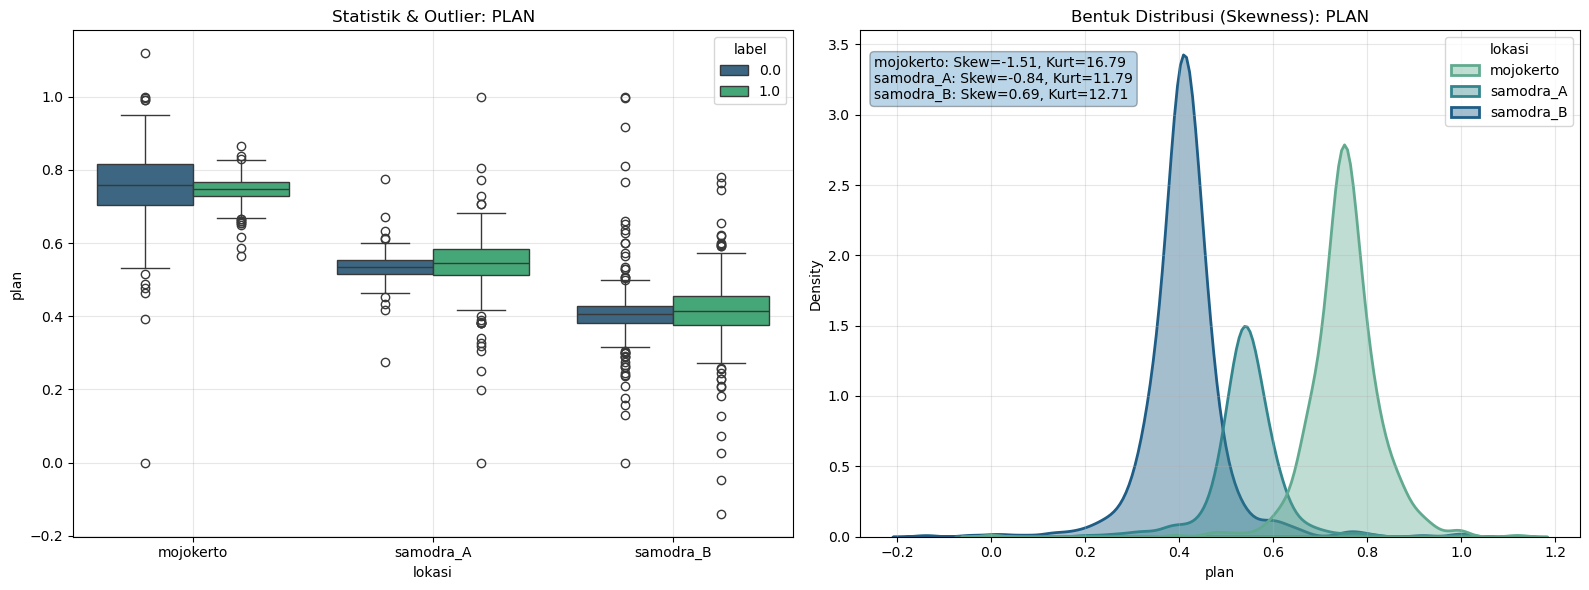

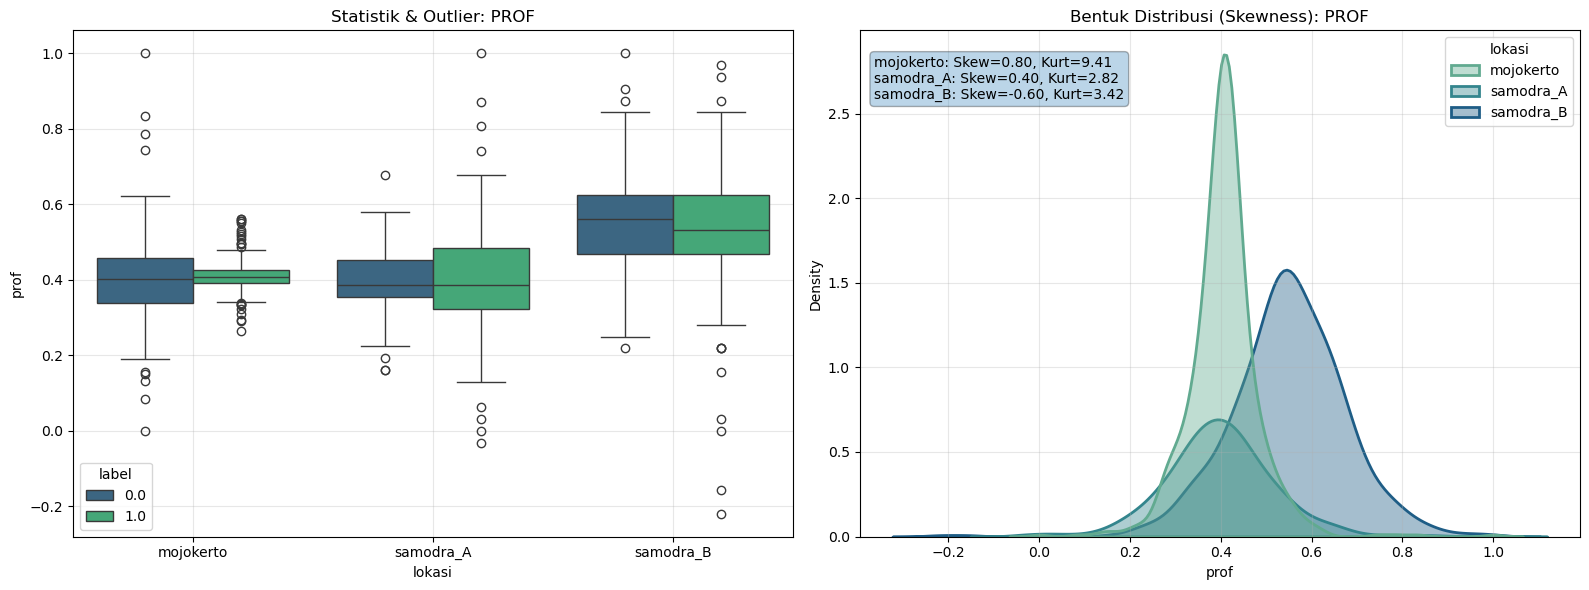

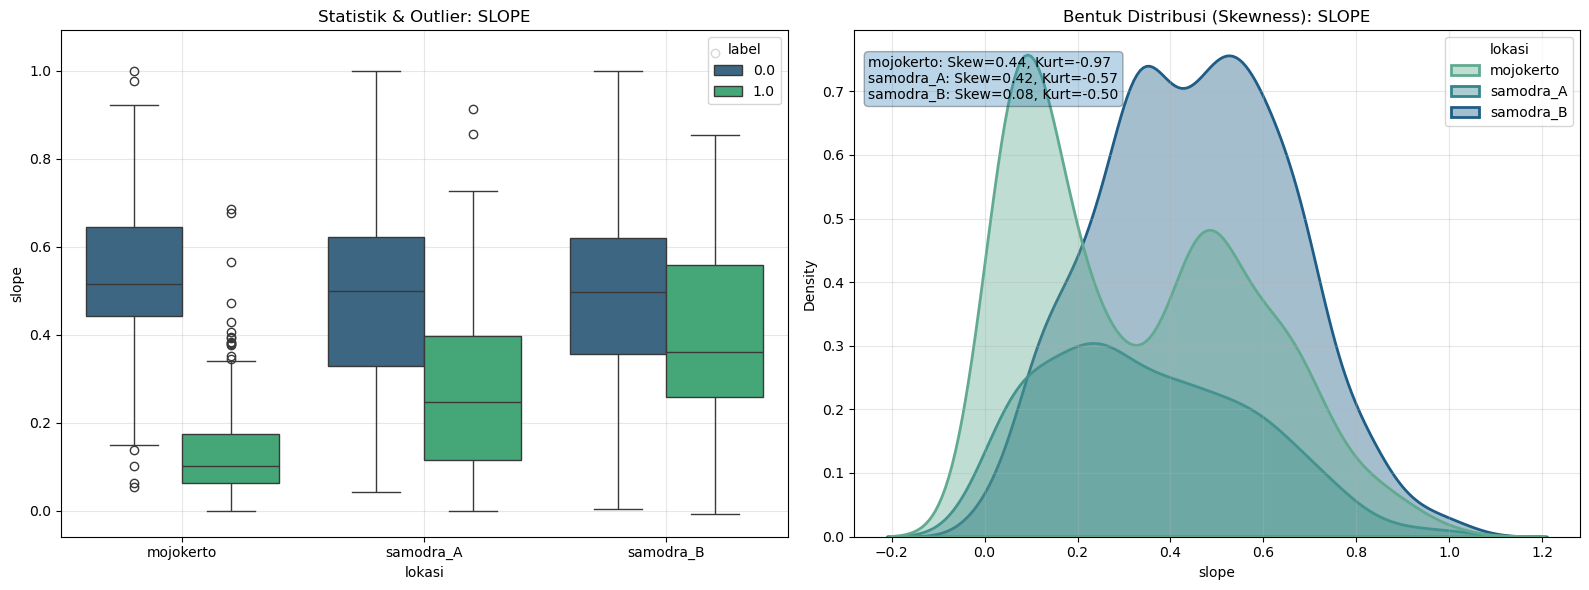

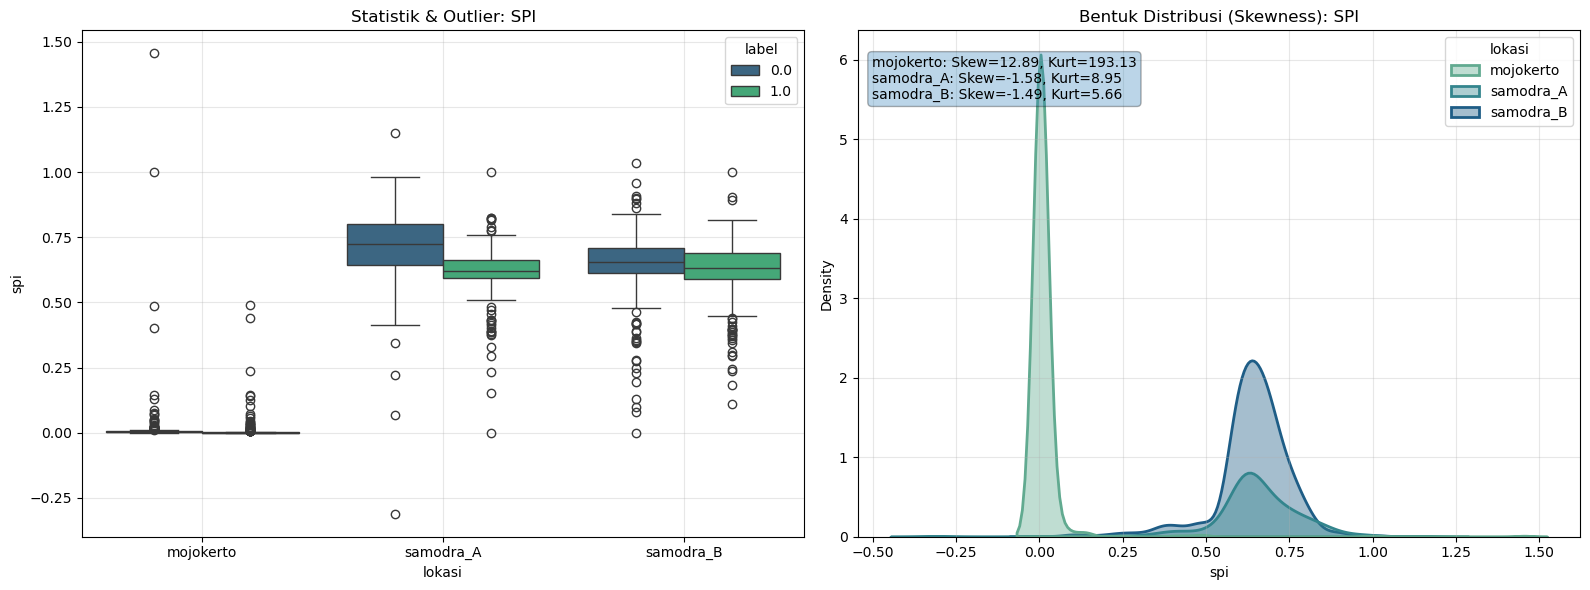

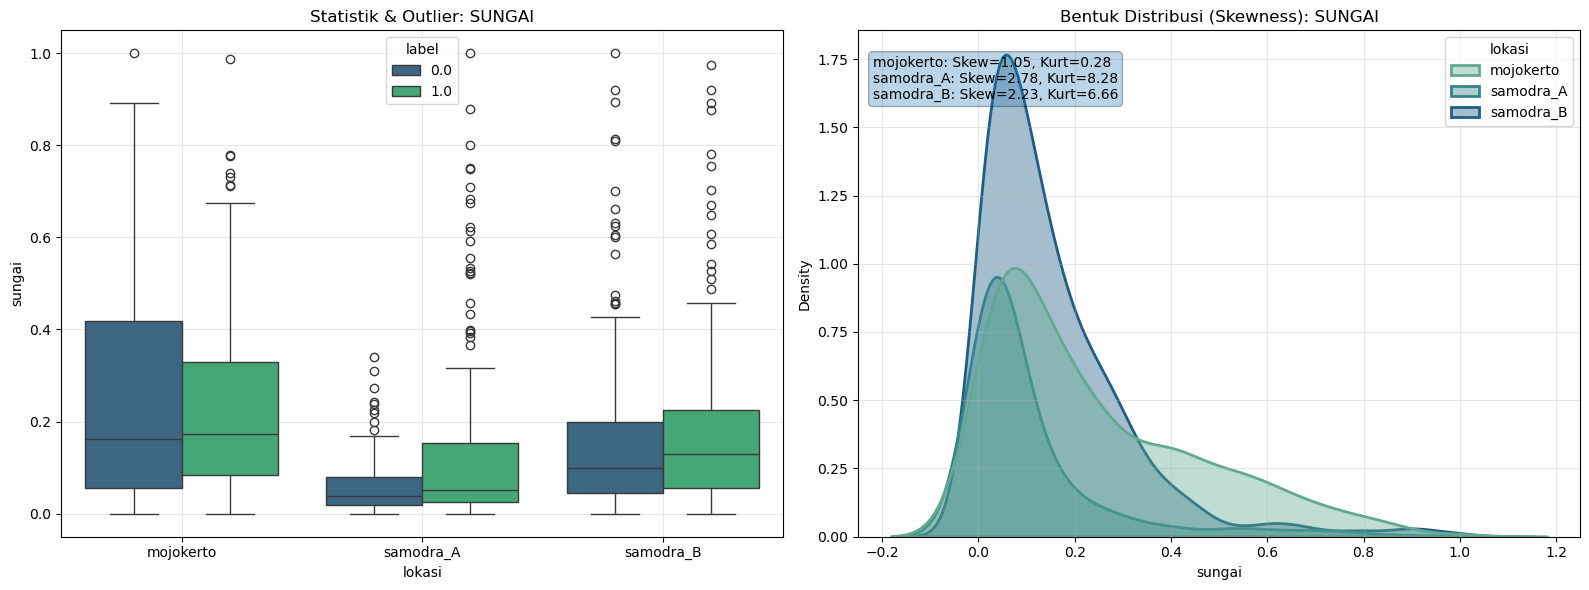

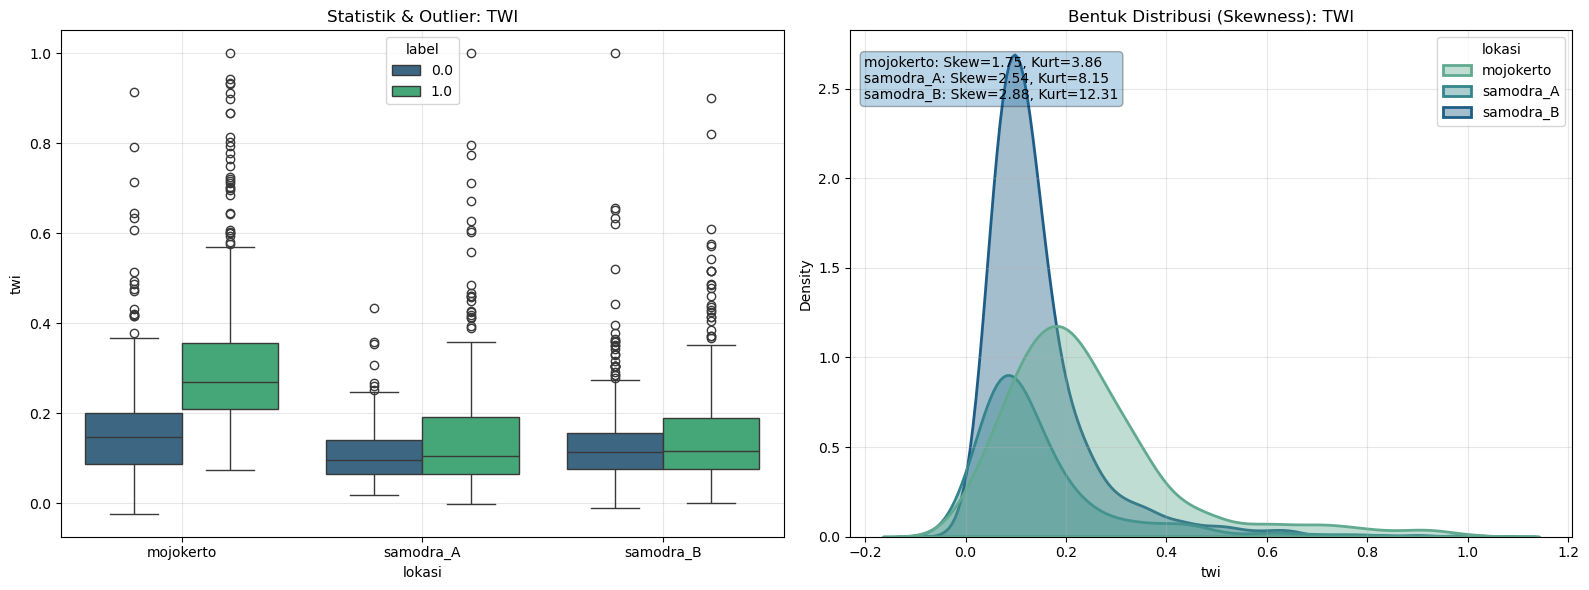

In [748]:
for col in num_cols:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot( data=final_df, x='lokasi', y=col, hue='label', palette='viridis')
    plt.title(f'Statistik & Outlier: {col.upper()}')
    plt.grid(True, alpha=0.3)
    plt.legend(title='label')

    plt.subplot(1, 2, 2)
    sns.kdeplot( data=final_df, x=col, hue='lokasi', fill=True, palette='crest', alpha=0.4, linewidth=2)

    text_lines = []
    for loc in final_df['lokasi'].unique():
        vals = final_df.loc[final_df['lokasi'] == loc, col].dropna()
        sk = skew(vals)
        ku = kurtosis(vals, fisher=True)
        text_lines.append(f"{loc}: Skew={sk:.2f}, Kurt={ku:.2f}")

    text = "\n".join(text_lines)

    plt.text(
        0.02, 0.95,
        text,
        transform=plt.gca().transAxes,
        va='top',
        bbox=dict(boxstyle="round", alpha=0.3)
    )

    plt.title(f'Bentuk Distribusi (Skewness): {col.upper()}')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [749]:
def scatter(df,features, ref_col='elevasi', label_col='label'):
    features = [c for c in features if c != ref_col]

    n_plots = len(features)
    n_rows = np.ceil(n_plots / 3).astype(int)

    plt.figure(figsize=(18, 12))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, 3, i)

        sns.scatterplot(
            data=df,
            x=col,
            y=ref_col,
            hue=label_col,
            style=label_col,
            s=80,
            alpha=0.7,
            palette='deep'
        )

        plt.title(f'{col} vs {ref_col}')
        plt.grid(True, alpha=0.3)
        plt.legend(title=label_col)

    plt.suptitle(
        f'Scatter Plot Semua Fitur Numerik vs {ref_col}\n'
        '(Analisis Separasi Kelas)',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


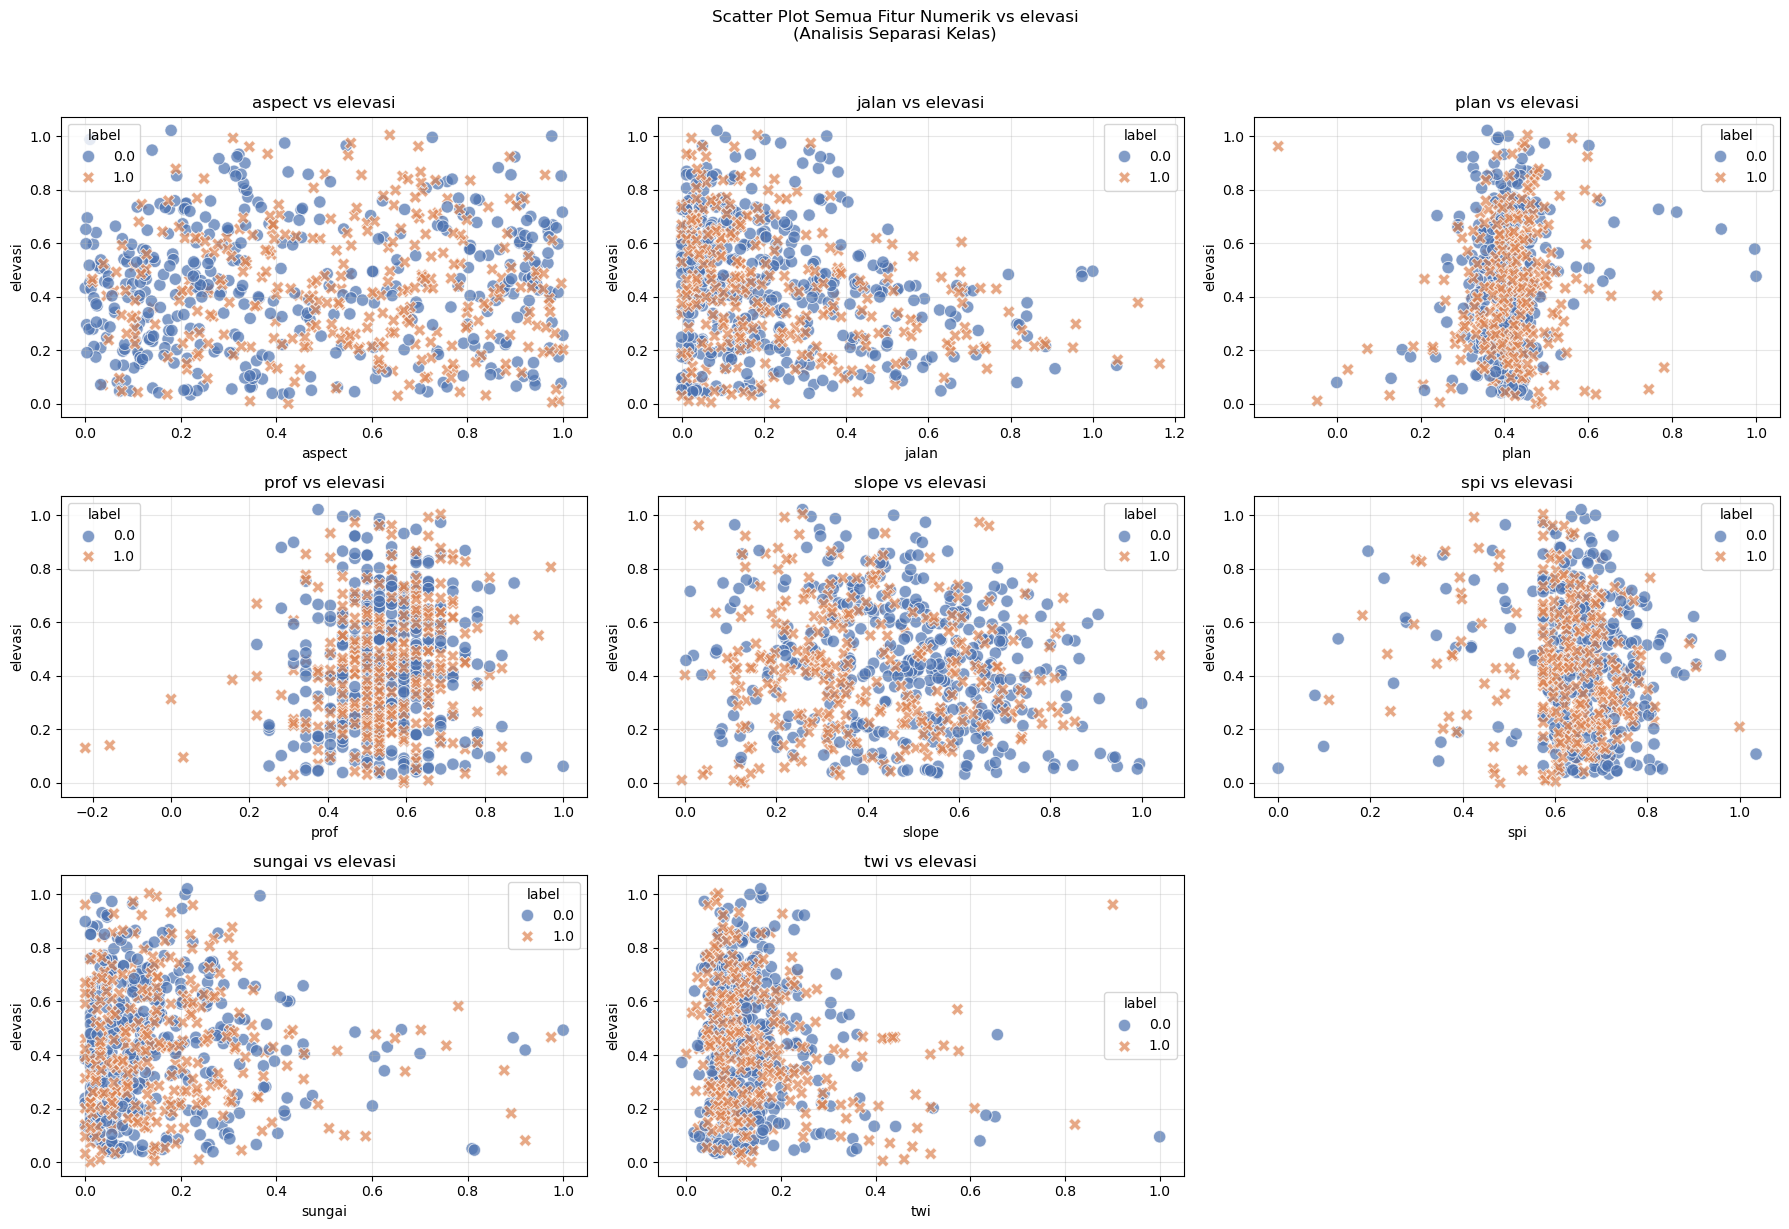

In [750]:
scatter(df_sam_B, num_cols, ref_col='elevasi')


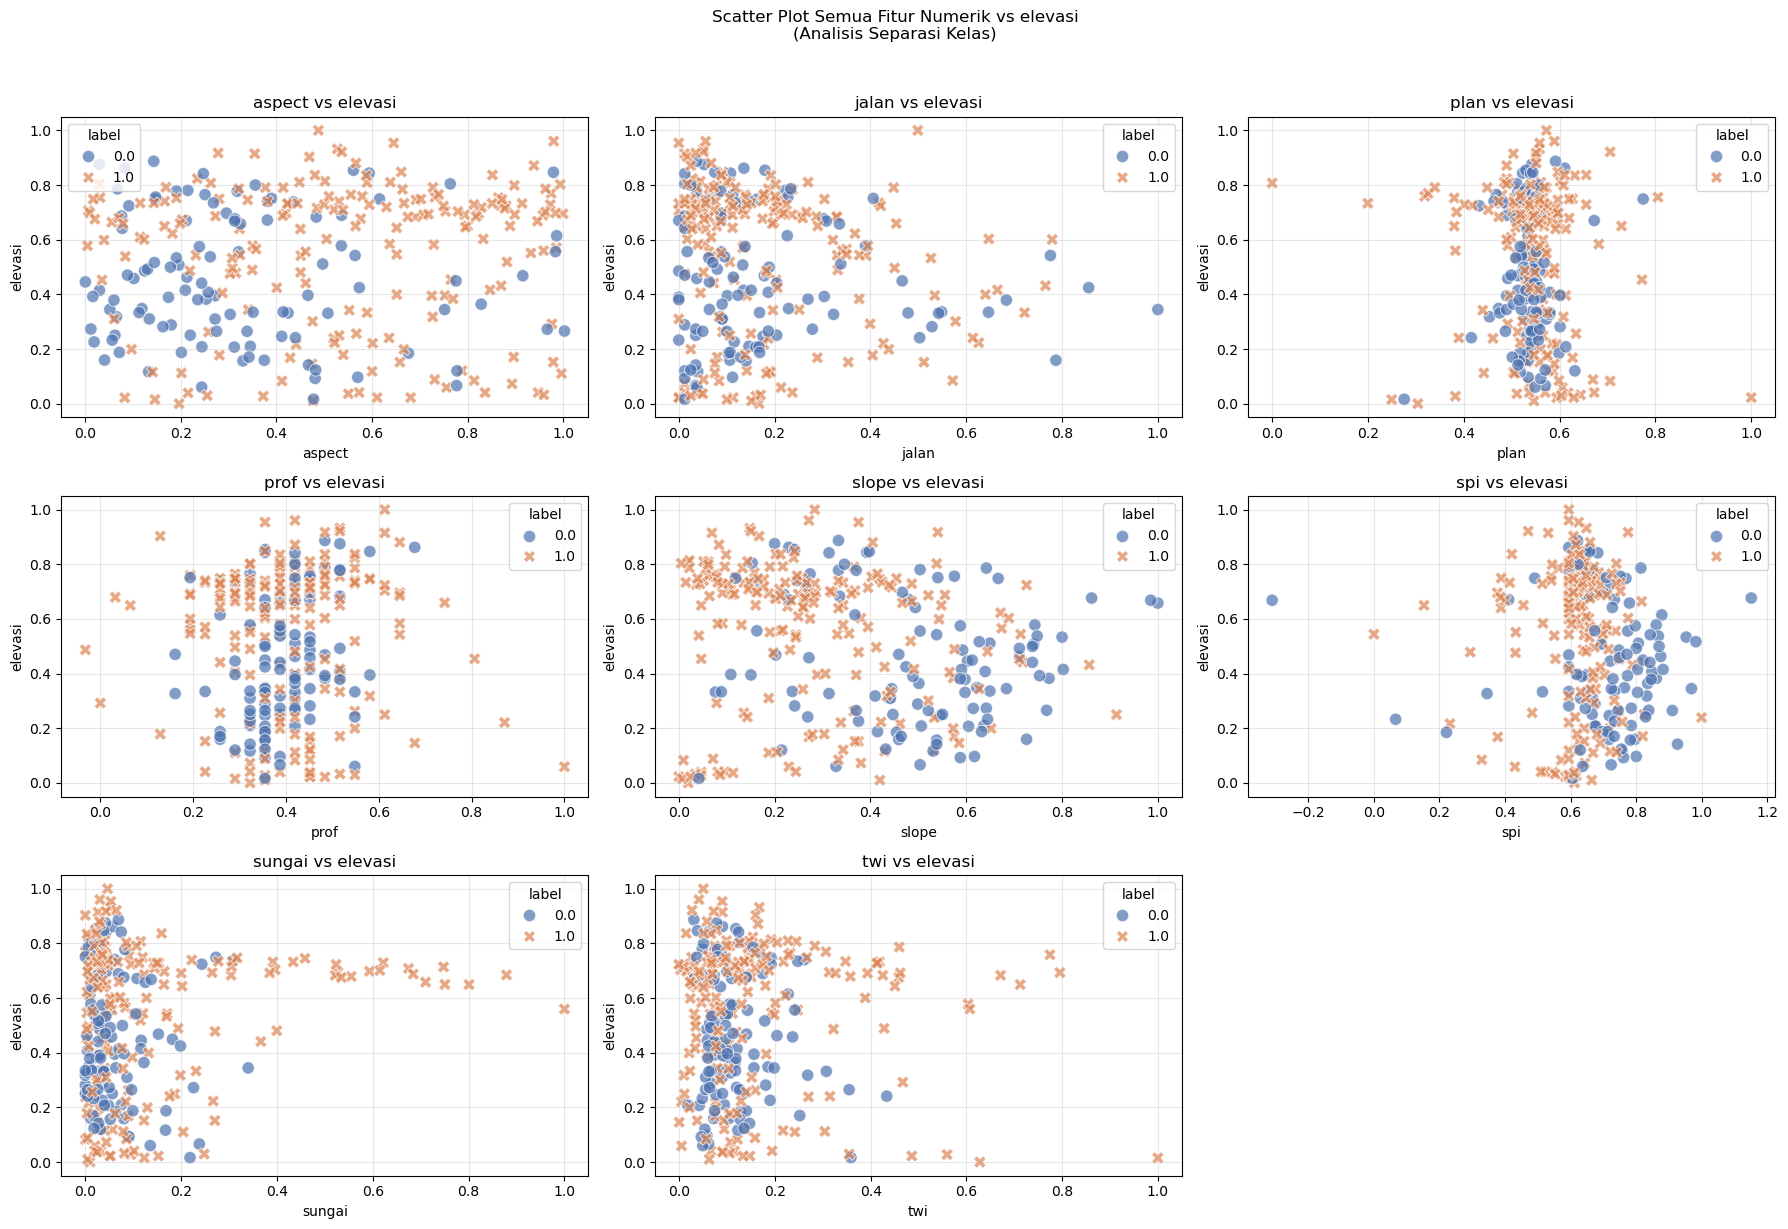

In [751]:
scatter(df_sam_A, num_cols, ref_col='elevasi')

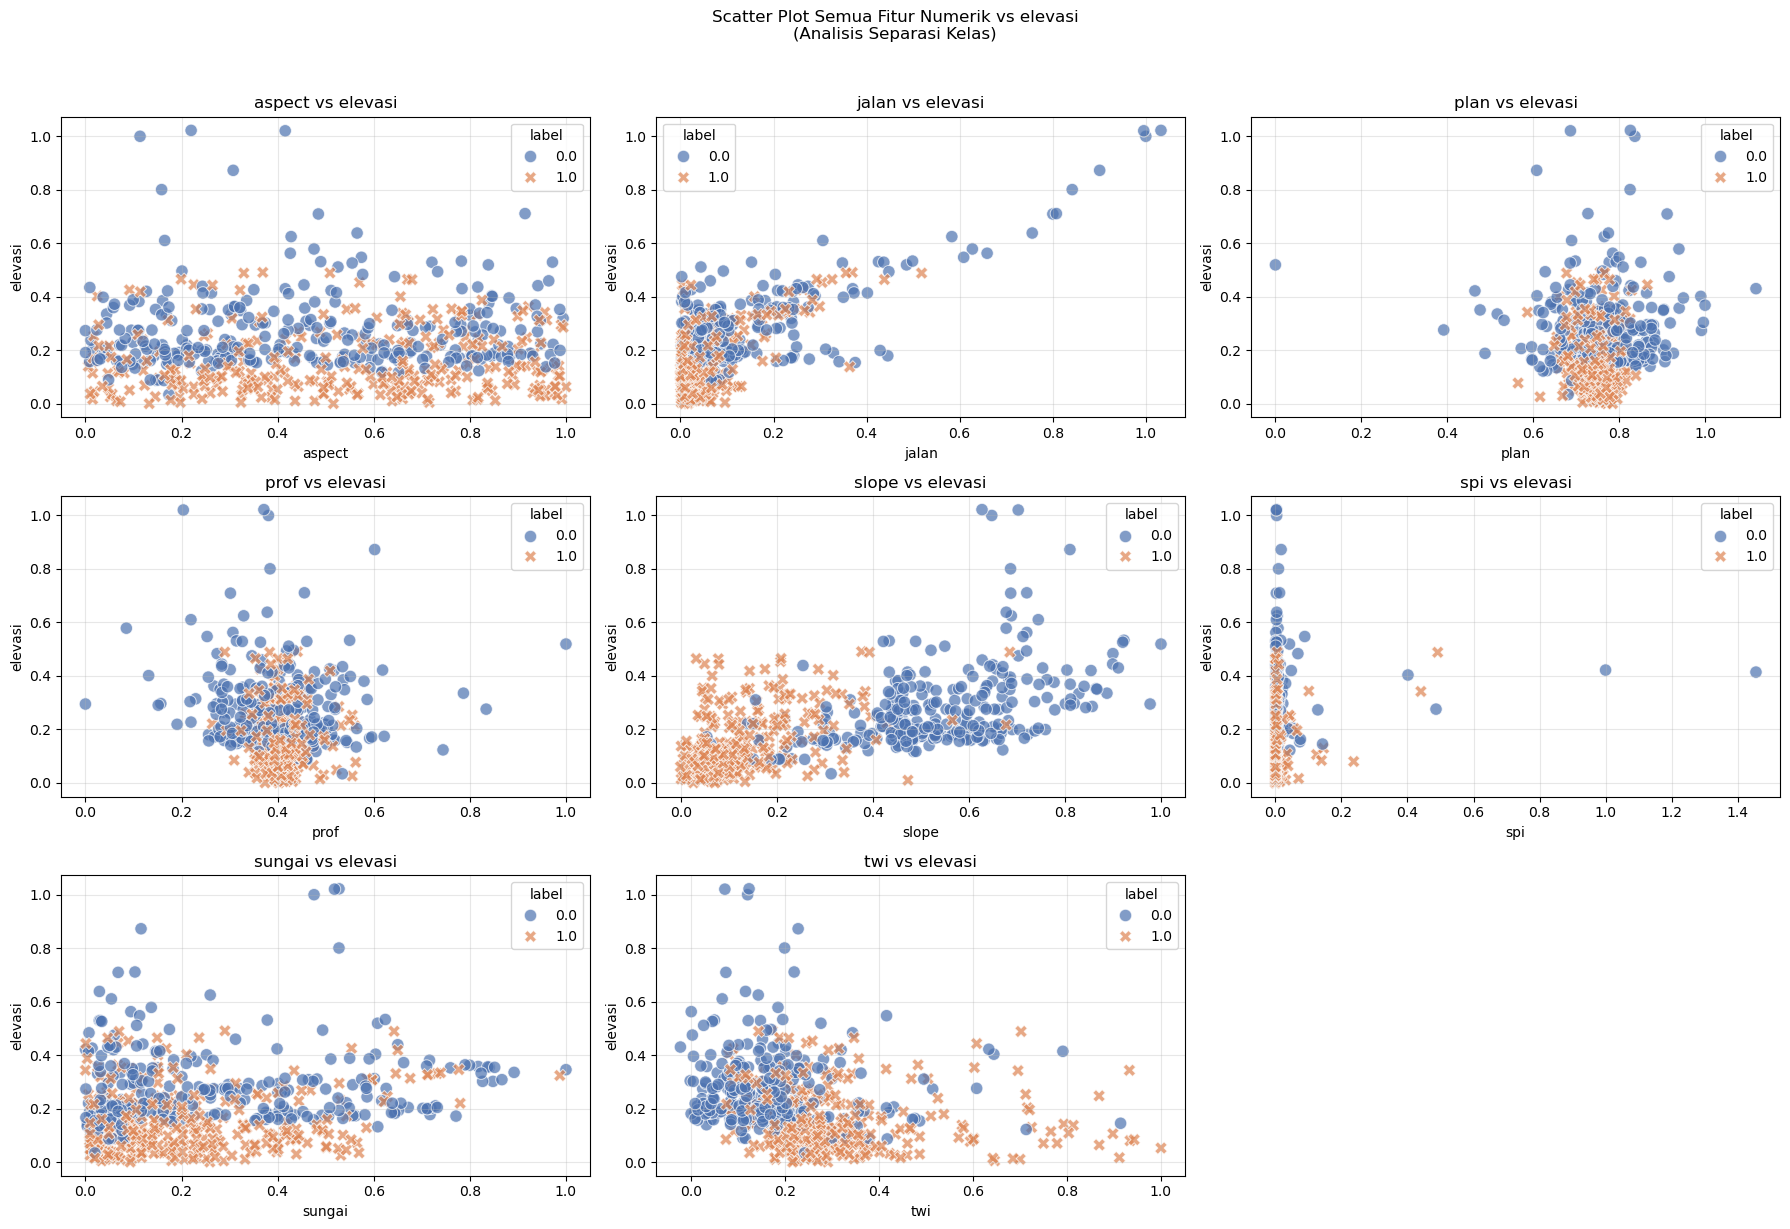

In [752]:
scatter(df_mjk, num_cols, ref_col='elevasi')

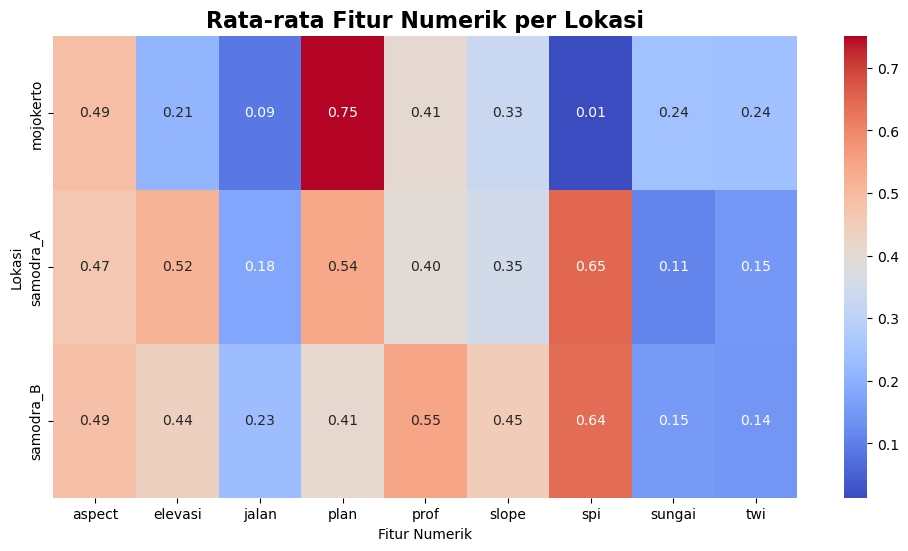

In [753]:
# sebaran data numerik per lokasi
avg = final_df.groupby('lokasi')[num_cols].mean()
plt.figure(figsize=(12, 6))
sns.heatmap(avg, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Rata-rata Fitur Numerik per Lokasi', fontsize=16, fontweight='bold')
plt.xlabel('Fitur Numerik')
plt.ylabel('Lokasi')
plt.show()


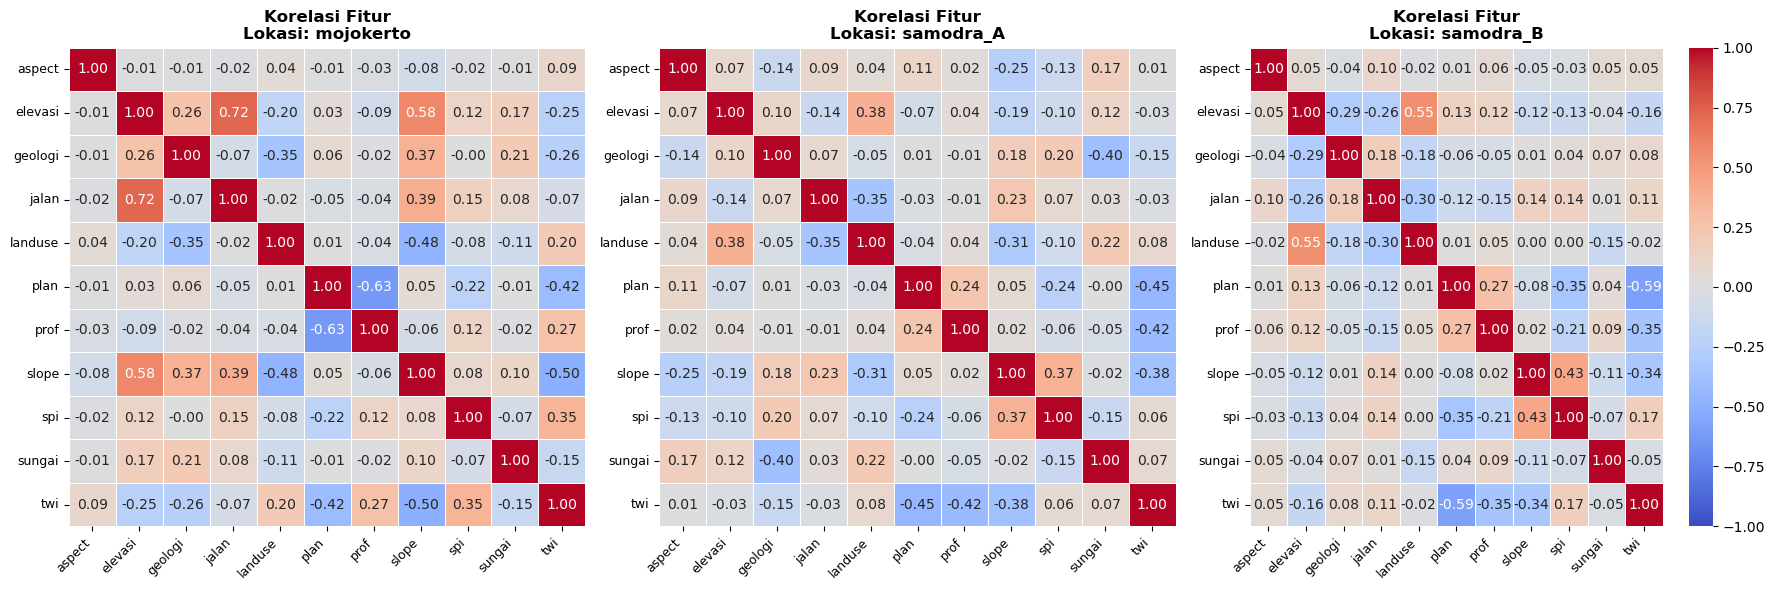

In [754]:
locations = final_df['lokasi'].unique()

plt.figure(figsize=(6 * len(locations), 6))
for i, loc in enumerate(locations, 1):
    df_subset = final_df[final_df['lokasi'] == loc][features]

    corr = df_subset.corr()
    plt.subplot(1, len(locations), i)

    sns.heatmap(
        corr,
        annot=True,           
        fmt=".2f",            
        cmap='coolwarm',
        vmin=-1, vmax=1,
        center=0,          
        linewidths=0.5,       
        cbar=i == len(locations) 
    )

    plt.title(f'Korelasi Fitur\nLokasi: {loc}', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## Preprocessing

In [755]:
final_df['stratify_col'] = final_df['lokasi'] + "_" + final_df['label'].astype(str)

In [756]:
final_df['aspect_sin'] = np.sin(2*np.pi*final_df['aspect'])
final_df['aspect_cos'] = np.cos(2*np.pi*final_df['aspect'])

In [757]:
final_df.columns

Index(['aspect', 'elevasi', 'geologi', 'jalan', 'landuse', 'plan', 'prof',
       'slope', 'spi', 'sungai', 'twi', 'label', 'lokasi', 'stratify_col',
       'aspect_sin', 'aspect_cos'],
      dtype='object')

In [758]:
X = final_df.drop(['label', 'lokasi', 'stratify_col'], axis=1)
y = final_df['label']
locations = final_df['lokasi'] 
    
# Split Data (80% Train, 20% Test)
# Menggunakan stratify_col agar proporsi Mojokerto/Samodra seimbang
X_train, X_test, y_train, y_test, loc_train, loc_test = train_test_split(
  X, y, locations, test_size=0.2, random_state=42, stratify=final_df['stratify_col']
)
    
print(f"\nJumlah Data Train: {len(X_train)} | Jumlah Data Test: {len(X_test)}")


Jumlah Data Train: 1288 | Jumlah Data Test: 322


In [759]:
def global_eval(test_pred, y_test, train_pred, y_train, model):
  print(f"TRAINING SET EVALUATION - {model}")
  print(f"Acuracy: {acc(y_train, train_pred)*100:.2f}%")
  print(f"Precision: {precis(y_train, train_pred)*100:.2f}%")
  print(f"Recall: {recall(y_train, train_pred)*100:.2f}%")
  print(f"F1-Score: {f1(y_train, train_pred)*100:.2f}%\n")

  print(f"TEST SET EVALUATION - {model}")
  print(f"Acuracy: {acc(y_test, test_pred)*100:.2f}%")
  print(f"Precision: {precis(y_test, test_pred)*100:.2f}%")
  print(f"Recall: {recall(y_test, test_pred)*100:.2f}%")
  print(f"F1-Score: {f1(y_test, test_pred)*100:.2f}%\n")

In [760]:
def rf_obj(trial):
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 2, 5),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 10, 40),
        min_samples_split=trial.suggest_int('min_samples_split', 5, 30),
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    return cross_val_score(rf, X_train, y_train, cv=cv, scoring='recall', n_jobs=1).mean()

In [761]:
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(rf_obj, n_trials=50)

best_params = study.best_params

rf_final = RandomForestClassifier(
    **best_params,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_final.fit(X_train, y_train)

[I 2025-12-14 09:41:57,774] A new study created in memory with name: no-name-a69d8d0a-0dbe-499d-a667-47e015ac45ee
[I 2025-12-14 09:41:58,755] Trial 0 finished with value: 0.748718910136233 and parameters: {'n_estimators': 144, 'max_depth': 5, 'min_samples_leaf': 32, 'min_samples_split': 20}. Best is trial 0 with value: 0.748718910136233.
[I 2025-12-14 09:41:59,260] Trial 1 finished with value: 0.7140357455318085 and parameters: {'n_estimators': 89, 'max_depth': 2, 'min_samples_leaf': 11, 'min_samples_split': 27}. Best is trial 0 with value: 0.748718910136233.
[I 2025-12-14 09:42:00,673] Trial 2 finished with value: 0.7313835770528685 and parameters: {'n_estimators': 200, 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 30}. Best is trial 0 with value: 0.748718910136233.
[I 2025-12-14 09:42:02,093] Trial 3 finished with value: 0.7077365329333833 and parameters: {'n_estimators': 258, 'max_depth': 2, 'min_samples_leaf': 15, 'min_samples_split': 9}. Best is trial 0 with value: 

,n_estimators,164
,criterion,'gini'
,max_depth,5
,min_samples_split,18
,min_samples_leaf,16
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [762]:
y_pred_rf_test = rf_final.predict(X_test)
y_pred_rf_train = rf_final.predict(X_train)

global_eval(y_pred_rf_test, y_test, y_pred_rf_train, y_train, model="RF")

TRAINING SET EVALUATION - RF
Acuracy: 80.43%
Precision: 81.28%
Recall: 78.20%
F1-Score: 79.71%

TEST SET EVALUATION - RF
Acuracy: 74.84%
Precision: 75.84%
Recall: 71.52%
F1-Score: 73.62%



In [763]:
def gb_obj(trial):
    gb = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1),
        max_depth=trial.suggest_int('max_depth', 2, 3),
        subsample=trial.suggest_float('subsample', 0.5, 0.8),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 10, 40),
        min_samples_split=trial.suggest_int('min_samples_split', 10, 40),
        loss='log_loss',
        max_features='sqrt',
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    return cross_val_score(
        gb,
        X_train,
        y_train,
        cv=cv,
        scoring='recall',
        n_jobs=1
    ).mean()

In [764]:
study.optimize(gb_obj, n_trials=50)

best_params = study.best_params

gb_final = GradientBoostingClassifier(
    **best_params,
    max_features='sqrt',

    random_state=42
)

gb_final.fit(X_train, y_train)

[I 2025-12-14 09:43:05,053] Trial 50 finished with value: 0.731408573928259 and parameters: {'n_estimators': 197, 'learning_rate': 0.022166455398524874, 'max_depth': 2, 'subsample': 0.5375558622680369, 'min_samples_leaf': 27, 'min_samples_split': 38}. Best is trial 6 with value: 0.7487314085739283.
[I 2025-12-14 09:43:05,673] Trial 51 finished with value: 0.7440194975628047 and parameters: {'n_estimators': 146, 'learning_rate': 0.09802691324914052, 'max_depth': 2, 'subsample': 0.7883055568182035, 'min_samples_leaf': 38, 'min_samples_split': 26}. Best is trial 6 with value: 0.7487314085739283.
[I 2025-12-14 09:43:06,093] Trial 52 finished with value: 0.7472315960504937 and parameters: {'n_estimators': 79, 'learning_rate': 0.07630751095555267, 'max_depth': 3, 'subsample': 0.704757460806677, 'min_samples_leaf': 32, 'min_samples_split': 17}. Best is trial 6 with value: 0.7487314085739283.
[I 2025-12-14 09:43:06,573] Trial 53 finished with value: 0.7124359455068117 and parameters: {'n_estim

,loss,'log_loss'
,learning_rate,0.08680865885909608
,n_estimators,125
,subsample,0.754556797329758
,criterion,'friedman_mse'
,min_samples_split,15
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [765]:
y_pred_gb_test = gb_final.predict(X_test)
y_pred_gb_train = gb_final.predict(X_train)

global_eval(y_pred_gb_test, y_test, y_pred_gb_train, y_train, model="GB")

TRAINING SET EVALUATION - GB
Acuracy: 87.42%
Precision: 88.54%
Recall: 85.47%
F1-Score: 86.98%

TEST SET EVALUATION - GB
Acuracy: 76.40%
Precision: 77.33%
Recall: 73.42%
F1-Score: 75.32%



In [766]:
def evaluasi_per_lokasi(model, X, y, locations, model_name="Model"):
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")
    
    y_pred_all = model.predict(X)
 
    unique_locations = locations.unique()
    
    for loc in unique_locations:
        mask = (locations == loc)
        
        y_true_loc = y[mask]
        y_pred_loc = y_pred_all[mask]
        
        print(f"\n[Lokasi: {loc}] - (Jumlah Sampel: {len(y_true_loc)})")
        print(f"  Accuracy : {acc(y_true_loc, y_pred_loc)*100:.2f}%")
        print(f"  Precision: {precis(y_true_loc, y_pred_loc)*100:.2f}%")
        print(f"  Recall   : {recall(y_true_loc, y_pred_loc)*100:.2f}%")
        print(f"  F1-Score : {f1(y_true_loc, y_pred_loc)*100:.2f}%")

evaluasi_per_lokasi(rf_final, X_test, y_test, loc_test, "Random Forest")

evaluasi_per_lokasi(gb_final, X_test, y_test, loc_test, "Gradient Boosting")


Random Forest

[Lokasi: samodra_B] - (Jumlah Sampel: 142)
  Accuracy : 62.68%
  Precision: 57.14%
  Recall   : 46.67%
  F1-Score : 51.38%

[Lokasi: mojokerto] - (Jumlah Sampel: 120)
  Accuracy : 88.33%
  Precision: 87.10%
  Recall   : 90.00%
  F1-Score : 88.52%

[Lokasi: samodra_A] - (Jumlah Sampel: 60)
  Accuracy : 76.67%
  Precision: 81.58%
  Recall   : 81.58%
  F1-Score : 81.58%

Gradient Boosting

[Lokasi: samodra_B] - (Jumlah Sampel: 142)
  Accuracy : 63.38%
  Precision: 58.00%
  Recall   : 48.33%
  F1-Score : 52.73%

[Lokasi: mojokerto] - (Jumlah Sampel: 120)
  Accuracy : 90.00%
  Precision: 91.38%
  Recall   : 88.33%
  F1-Score : 89.83%

[Lokasi: samodra_A] - (Jumlah Sampel: 60)
  Accuracy : 80.00%
  Precision: 80.95%
  Recall   : 89.47%
  F1-Score : 85.00%


In [767]:
model_artifact = {
    'model': rf_final,
    'features': X.columns.tolist(),
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'random_state': 42,
}
joblib.dump(model_artifact, 'Model/rf.pkl')

model_artifact_gb = {
    'model': gb_final,
    'features': X.columns.tolist(),
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'random_state': 42,
}
joblib.dump(model_artifact_gb, 'Model/gb.pkl')


['Model/gb.pkl']

In [768]:
# #load
# artefact = joblib.load('Model/rf.pkl')
# rf_model = artefact['model']

In [769]:
#roc curve
from sklearn.metrics import roc_auc_score
y_prob_rf_test = rf_final.predict_proba(X_test)[:, 1]
y_prob_gb_test = gb_final.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf_test)
auc_gb = roc_auc_score(y_test, y_prob_gb_test)
print(f"ROC AUC - Random Forest: {auc_rf:.4f}")
print(f"ROC AUC - Gradient Boosting: {auc_gb:.4f}")

ROC AUC - Random Forest: 0.8613
ROC AUC - Gradient Boosting: 0.8720


## Note
Dari scatter plot, tumpang tindih jelas di data samodra, buat model susah belajar karena 0 dan 1 bercampur. 
